In [8]:
import time
# Start timing script
start_time = time.time()

import datetime
import json
import os

import jax.numpy as jnp
import jax
import numpy as np
import pandas as pd

import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [9]:
# ====================
# 1. FACTORY FUNCTIONS
# ====================
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [10]:
# ===============
# 2. DATA LOADING 
# ===============
def prepare_margarine_data(filepath):
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list = []
    y_list = []
    Z_list = []
    unit_indices = []
    
    n_alts_orig = 10
    kept_alts_1based = np.array([1, 2, 3, 4, 5, 7])
    kept_alts_0based = kept_alts_1based - 1 
    p = len(kept_alts_0based) 
    y_mapping = {val: idx for idx, val in enumerate(kept_alts_1based)}
    unit_idx_counter = 0
    
    for respondent in raw_data:
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        if y_raw.ndim == 0:
            y_raw = np.atleast_1d(y_raw)
        
        n_choice_occasions_orig = len(y_raw)
        n_params_orig = X_raw.shape[1]
        X_reshaped = X_raw.reshape((n_choice_occasions_orig, n_alts_orig, n_params_orig))
        
        valid_occasions = np.isin(y_raw, kept_alts_1based)
        y_filtered = y_raw[valid_occasions]
        X_filtered = X_reshaped[valid_occasions]
        
        n_obs = len(y_filtered)
        if n_obs < 5:
            continue
            
        Z_raw = np.array(respondent.get('Z_raw', [1.0, 1.0]))
        Z_list.append(Z_raw)
        y_recoded = np.array([y_mapping[val] for val in y_filtered])
        X_new = np.zeros((n_obs, p, p))
        
        for r in range(n_obs):
            orig_prices = X_filtered[r, kept_alts_0based, 9]
            log_prices = np.log(orig_prices)
            X_new[r, 1:, 0:5] = np.eye(5)
            X_new[r, :, 5] = log_prices
            
        X_list.append(X_new)
        y_list.append(y_recoded)
        unit_indices.extend([unit_idx_counter] * n_obs)
        unit_idx_counter += 1

    # ==========================================
    # Post-process Demographics (UPDATED)
    # ==========================================
    Z_arr = np.array(Z_list)
    
    # Log only the Income column (assumed to be index 0).
    # Leave Family Size (assumed index 1) as a linear integer.
    Z_arr[:, 0] = np.log(Z_arr[:, 0])
    
    # We remove the mean-centering line (Z_arr = Z_arr - np.mean(Z_arr, axis=0)) 
    # to maintain the original paper's extrapolation for the intercept.
    
    # Add intercept column to Z so the first row of Delta acts as the baseline mu
    Z_intercept = np.ones((Z_arr.shape[0], 1))
    Z_final = np.concatenate([Z_intercept, Z_arr], axis=1)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "Z": jnp.array(Z_final),
        "unit_idx": jnp.array(unit_indices),
        "n_units": unit_idx_counter,
        "n_params": p,
        "n_z": Z_final.shape[1]
    }

script_location = os.path.abspath(os.getcwd())
json_path = os.path.join(script_location, "..", "Data", "margarine_data_new.json")
data_dict = prepare_margarine_data(json_path)

k_dim = int(data_dict["n_params"]) 
n_units = int(data_dict["n_units"])
n_z = int(data_dict["n_z"])

print(f"Data Loaded: {n_units} units, {k_dim} parameters, {n_z} demographic vars (including intercept)")
print(f"Total Observations: {data_dict['y'].shape[0]}")

Data Loaded: 313 units, 6 parameters, 3 demographic vars (including intercept)
Total Observations: 3405


In [11]:
# =================
# 3. MODEL BUILDING
# =================

# Constants
nu_val = float(k_dim + 3)
V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)
A_val = 0.01

# V_beta inverse (precision matrix)
sigma_inv_chol = lsl.Var.new_param(
    value=jnp.eye(k_dim),
    distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
    name="sigma_inv_chol"
)

sigma_inv_chol_latent = sigma_inv_chol.transform(
    tfb.FillScaleTriL(), 
    name="sigma_inv_chol_latent"
)

# MRM Prior for Delta: precision of each row is conditionally dependent on sigma_inv_chol
delta_prec_factor = lsl.Var.new_calc(
    lambda L: jnp.sqrt(A_val) * L, 
    L=sigma_inv_chol, 
    name="delta_prec_factor"
)

# Delta replaces 'mu'. Shape is (n_z, k_dim). 
# Row 0 = Intercepts, Row 1 = Income effects, Row 2 = Fam Size effects
Delta = lsl.Var.new_param(
    value=jnp.zeros((n_z, k_dim)),
    distribution=lsl.Dist(
        make_mvn_precision, 
        loc=jnp.zeros(k_dim), 
        precision_factor=delta_prec_factor
    ),
    name="Delta"
)

# Calculate Beta Mean: B = Z * Delta
Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
beta_mean = lsl.Var.new_calc(
    lambda Z, D: jnp.dot(Z, D),
    Z=Z_var,
    D=Delta,
    name="beta_mean"
)

# Unit-level parameters
beta_i = lsl.Var.new_param(
    value=jnp.zeros((n_units, k_dim)),
    distribution=lsl.Dist(make_mvn_precision, loc=beta_mean, precision_factor=sigma_inv_chol),
    name="beta_i"
)

# Observation Model
X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

beta_expanded = lsl.Var.new_calc(
    lambda b, idx: b[idx], 
    b=beta_i, 
    idx=idx_var, 
    name="beta_expanded"
)

logits = lsl.Var.new_calc(
    lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
    x=X_var, 
    b=beta_expanded, 
    name="logits"
)

y_var = lsl.Var.new_obs(
    data_dict["y"], 
    distribution=lsl.Dist(tfd.Categorical, logits=logits), 
    name="y"
)

model = lsl.Model([y_var])

c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [12]:
# ============
# 4. INFERENCE
# ============
eb = gs.EngineBuilder(seed=123, num_chains=1)
eb.set_model(gs.LieselInterface(model))
eb.set_initial_values(model.state)

# Kernels for sampling
eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
eb.add_kernel(gs.NUTSKernel(["Delta"])) 
eb.add_kernel(gs.NUTSKernel(["beta_i"]))

# Duration
eb.set_duration(warmup_duration=1000, posterior_duration=10000)

print("Starting Sampling...")
engine = eb.build()
engine.sample_all_epochs()

results = engine.get_results()
samples = results.get_posterior_samples()

liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:18<00:00,  6.21s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 6 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 7 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 415.20chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 4 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - IN

In [13]:
# Check runtime
end_time = time.time()
total_seconds = end_time - start_time
formatted_time = str(datetime.timedelta(seconds=int(total_seconds)))
print(f"Script finished in {formatted_time} (H:M:S)")

Script finished in 0:05:17 (H:M:S)


In [14]:
# ==========================================
# REPRODUCING TABLE 5.2: Posterior of Delta
# ==========================================

param_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "LogPrice"]
demo_names = ["Intercept", "log(Income)", "Family size"]

delta_draws = samples["Delta"].reshape(-1, len(demo_names), k_dim)

delta_mean = np.mean(delta_draws, axis=0)
delta_std = np.std(delta_draws, axis=0)

print("=== TABLE 5.2: Posterior distribution of Delta ===")
delta_df = pd.DataFrame(index=demo_names, columns=param_names)

for i in range(len(demo_names)):
    for j in range(k_dim):
        delta_df.iloc[i, j] = f"{delta_mean[i, j]: .2f} ({delta_std[i, j]:.2f})"

display(delta_df)
print("\n")


# ===============================================
# REPRODUCING TABLE 5.1: Covariance / Correlation
# ===============================================
# Extract latent samples and flatten the chains
# For k=6, the latent vector size is 6 * 7 / 2 = 21
latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))

# Setup the bijector (must match the model definition)
bijector = tfb.FillScaleTriL()

# Function to turn 1D vector -> Lower Triangular Matrix -> Covariance Matrix
def latent_to_cov(latent_vec):
    # L is the Cholesky factor of the precision matrix (V_inv)
    L = bijector.forward(latent_vec)
    
    # Precision = L @ L.T
    precision_mat = L @ L.T
    
    # Covariance = inv(Precision)
    return jnp.linalg.inv(precision_mat)

# Vectorize across all draws for fast computation
v_latent_to_cov = jax.vmap(latent_to_cov)
cov_draws = np.array(v_latent_to_cov(latent_samples)) # Convert back to NumPy for easier indexing

n_draws = cov_draws.shape[0]
std_draws = np.zeros((n_draws, k_dim))
corr_draws = np.zeros((n_draws, k_dim, k_dim))

# Transform Covariance to Stds and Correlations per draw
# Extract diagonals across the entire batch of draws simultaneously
std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))

# Create the outer product of standard deviations for the whole batch
outer_stds = std_draws[:, :, None] * std_draws[:, None, :]

# Divide the batch of covariances by the batch of outer products
corr_draws = cov_draws / outer_stds

# Calculate Posterior Means and Standard Deviations
std_mean = np.mean(std_draws, axis=0)
std_sd = np.std(std_draws, axis=0)

corr_mean = np.mean(corr_draws, axis=0)
corr_sd = np.std(corr_draws, axis=0)

print("=== TABLE 5.1: Correlations and standard deviations of betas ===")
table_5_1_df = pd.DataFrame(index=param_names, columns=param_names)

for i in range(k_dim):
    for j in range(k_dim):
        if i == j:
            # Diagonal: Standard Deviations
            table_5_1_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
        elif j > i:
            # Upper triangle: Correlations
            table_5_1_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
        else:
            # Lower triangle: leave blank
            table_5_1_df.iloc[i, j] = ""

display(table_5_1_df)

=== TABLE 5.2: Posterior distribution of Delta ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,LogPrice
Intercept,-1.22 (0.67),-3.66 (2.22),-3.30 (0.94),-5.15 (1.24),0.11 (1.28),-3.47 (0.87)
log(Income),0.05 (0.22),0.81 (0.71),0.03 (0.31),-0.51 (0.42),-0.65 (0.43),-0.30 (0.29)
Family size,-0.03 (0.10),-0.81 (0.34),0.24 (0.14),0.58 (0.18),0.05 (0.21),0.12 (0.13)




=== TABLE 5.1: Correlations and standard deviations of betas ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,LogPrice
Blue Bonnet,1.54 (0.13),0.35 (0.15),0.42 (0.10),0.44 (0.10),0.28 (0.12),-0.11 (0.15)
Fleischmanns,,3.99 (0.63),0.23 (0.15),0.12 (0.18),0.09 (0.18),0.36 (0.17)
House,,,2.39 (0.18),0.85 (0.04),0.48 (0.10),-0.12 (0.15)
Generic,,,,2.95 (0.26),0.54 (0.10),-0.23 (0.15)
Shed Spread,,,,,3.04 (0.33),0.06 (0.16)
LogPrice,,,,,,1.43 (0.19)


![alt text](image.png)

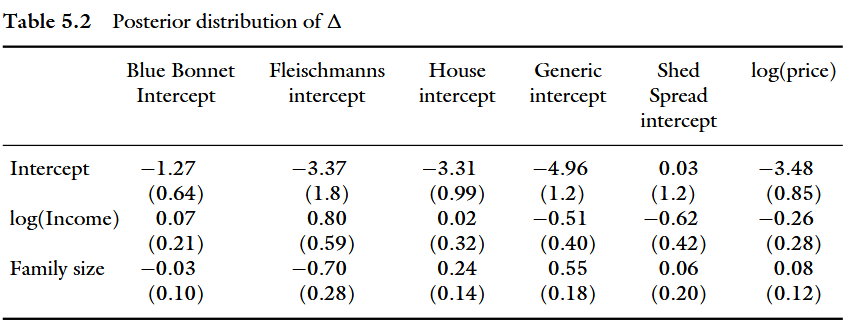